In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("diabetes.csv")
print("First 5 records:")
print(df.head())

First 5 records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
print("\nDataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())


Dataset Shape: (768, 9)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None


In [4]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [5]:
cols = ["Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI"]

In [6]:
X[cols] = X[cols].replace(0, np.nan)

In [7]:
X[cols] = X[cols].fillna(X[cols].median())

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

ImportError: DLL load failed while importing _argkmin: An Application Control policy has blocked this file.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
X_train


array([[-0.85135507, -1.0568694 , -0.82668697, ..., -0.76615019,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.1428554 ,  0.4770088 , ..., -0.41444809,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.55698407, -1.15261091, ...,  0.36222739,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.82358958, -0.17483909, ...,  0.83116352,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.35702994, -0.17483909, ..., -0.72218742,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.74271779, -1.15261091, ..., -0.42910234,
        -0.57700104,  0.30730824]], shape=(614, 8))

In [ ]:
X_test

array([[ 0.96054099,  1.24260312, -0.663725  , ..., -0.73684168,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.79003455,  2.7584764 , ...,  0.45015291,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.00955264,  0.31404683, ...,  0.50876993,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.32347491, -1.64149683, ..., -0.57564488,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.07574534,  0.4770088 , ...,  0.66996673,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.69005749,  0.4770088 , ...,  0.11310507,
        -0.16794879, -1.04589487]], shape=(154, 8))

In [ ]:
y_train

353    0
711    0
373    0
46     0
682    0
      ..
451    1
113    0
556    0
667    1
107    0
Name: Outcome, Length: 614, dtype: int64

In [ ]:
y_test

44     0
672    0
700    0
630    1
81     0
      ..
32     0
637    0
593    0
425    1
273    0
Name: Outcome, Length: 154, dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 1 0 1
 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 0 0 1 0]


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- MODEL EVALUATION ---")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- MODEL EVALUATION ---
Accuracy : 0.7078
Precision: 0.5882
Recall   : 0.5556
F1 Score : 0.5714

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



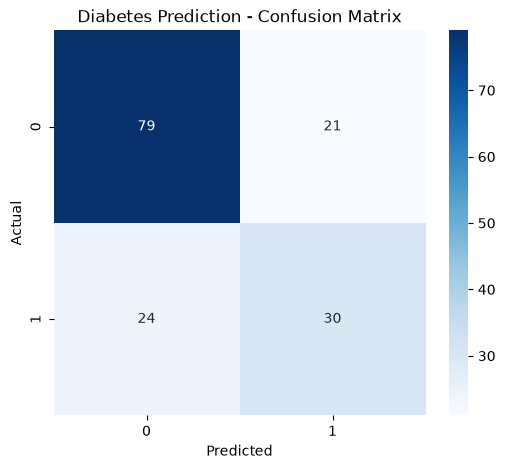

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Diabetes Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

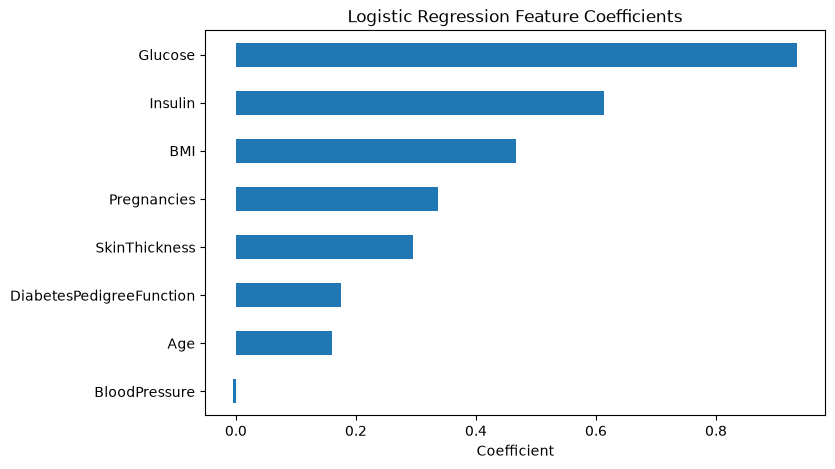

In [ ]:
importance = pd.Series(
    model.coef_[0],
    index=df.drop("Outcome", axis=1).columns
).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.show()

In [ ]:
sample = np.array([[2, 120, 70, 25, 80, 30.5, 0.45, 35]])

sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)[0]
probability = model.predict_proba(sample_scaled)[0][1]

print("\n--- SAMPLE PREDICTION ---")
print("Predicted Class:", prediction)
print("Estimated model probability:", round(probability, 3))

if prediction == 1:
    print("Model prediction: Diabetes class")
else:
    print("Model prediction: Non-diabetes class")


--- SAMPLE PREDICTION ---
Predicted Class: 0
Estimated model probability: 0.139
Model prediction: Non-diabetes class


C:\Users\ADC\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
